In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
folder = "/content/drive/MyDrive/FP_AI_2026"
print(os.listdir(folder))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['OpenDataset.csv', 'data', 'models', 'HumanVsAI_CodeDataset.csv', 'self_construction_dataset.csv', 'FinalDataset.csv', 'compare']


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (8,5)

In [ ]:
import pandas as pd

open_df = pd.read_csv(
    "/content/drive/MyDrive/FP_AI_2026/OpenDataset.csv"
)

self_df = pd.read_csv(
    "/content/drive/MyDrive/FP_AI_2026/self_construction_dataset.csv"
)

print("="*50)
print("OPEN DATASET")
print("="*50)

print(open_df.shape)

print(
    pd.crosstab(
        open_df["Language"],
        open_df["Generated"]
    )
)

print("="*50)
print("SELF CONSTRUCTION")
print("="*50)

print(self_df.shape)

print(
    pd.crosstab(
        self_df["Language"],
        self_df["Generated"]
    )
)


print("Columns Open Dataset")
print(open_df.columns)

print()

print("Columns Self Dataset")
print(self_df.columns)


final_df = pd.concat(
    [open_df, self_df],
    ignore_index=True
)

print("="*50)
print("FINAL DATASET")
print("="*50)

print(final_df.shape)

print("\nGenerated Distribution")
print(
    final_df["Generated"].value_counts()
)

print("\nLanguage Distribution")
print(
    final_df["Language"].value_counts()
)

print("\nSource Distribution")
print(
    final_df["Source"].value_counts()
)

print("\nMissing Values")
print(
    final_df.isnull().sum()
)

print("\nDuplicate Rows")
print(
    final_df.duplicated().sum()
)

print("\nDuplicate Code")
print(
    final_df.duplicated(
        subset=["Sample_Code"]
    ).sum()
)

final_df.to_csv(
    "/content/drive/MyDrive/FP_AI_2026/FinalDataset.csv",
    index=False
)

print("\nFinalDataset.csv berhasil disimpan")

OPEN DATASET
(700, 5)
Generated  AI  Human
Language            
C          79     61
C++        84     89
Java       89    120
Python     98     80
SELF CONSTRUCTION
(300, 5)
Generated  AI  Human
Language            
C++        50     50
Java       50     50
Python     50     50
Columns Open Dataset
Index(['problem_id', 'Sample_Code', 'Generated', 'Language', 'Source'], dtype='object')

Columns Self Dataset
Index(['problem_id', 'Sample_Code', 'Generated', 'Language', 'Source'], dtype='object')
FINAL DATASET
(1000, 5)

Generated Distribution
Generated
Human    500
AI       500
Name: count, dtype: int64

Language Distribution
Language
Java      309
Python    278
C++       273
C         140
Name: count, dtype: int64

Source Distribution
Source
CodeNet        350
ChatGPT-4      253
GitHub         150
ChatGPT-3.5     97
Claude          57
Gemini          50
ChatGPT         43
Name: count, dtype: int64

Missing Values
problem_id     0
Sample_Code    0
Generated      0
Language       0
Source

In [ ]:
print("="*50)
print("DATASET INFO")
print("="*50)

print(final_df.info())

print()

print("="*50)
print("DESCRIPTIVE STATISTICS")
print("="*50)

display(final_df.describe(include="all"))

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   problem_id   1000 non-null   object
 1   Sample_Code  1000 non-null   object
 2   Generated    1000 non-null   object
 3   Language     1000 non-null   object
 4   Source       1000 non-null   object
dtypes: object(5)
memory usage: 39.2+ KB
None

DESCRIPTIVE STATISTICS


,problem_id,Sample_Code,Generated,Language,Source
count,1000,1000,1000,1000,1000
unique,972,1000,2,4,7
top,Prob1076,#include <iostream>\n#include <sstream>\nusing...,Human,Java,CodeNet
freq,2,1,500,309,350


problem_id     0
Sample_Code    0
Generated      0
Language       0
Source         0
dtype: int64


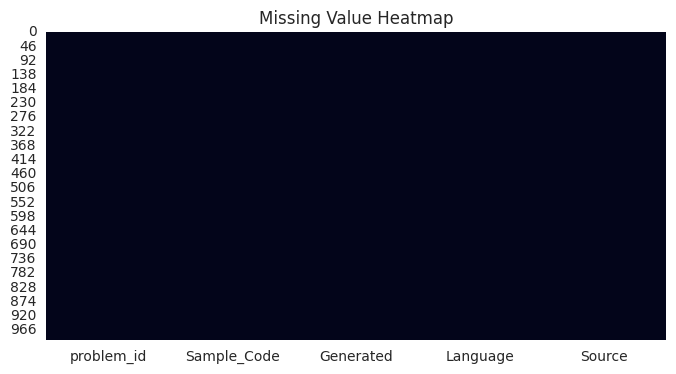

In [ ]:
missing = final_df.isnull().sum()

print(missing)

plt.figure(figsize=(8,4))

sns.heatmap(
    final_df.isnull(),
    cbar=False
)

plt.title("Missing Value Heatmap")

plt.show()


In [ ]:
print(
    "Duplicate Rows:",
    final_df.duplicated().sum()
)

print(
    "Duplicate Code:",
    final_df.duplicated(
        subset=["Sample_Code"]
    ).sum()
)

Duplicate Rows: 0
Duplicate Code: 0


Generated
Human    500
AI       500
Name: count, dtype: int64


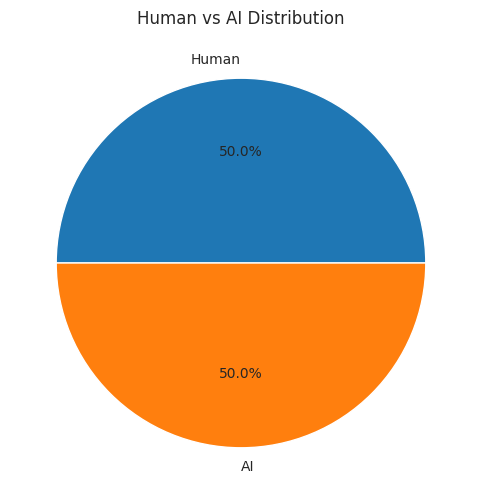

In [ ]:
print(
    final_df["Generated"]
    .value_counts()
)

generated_counts = (
    final_df["Generated"]
    .value_counts()
)

plt.figure(figsize=(6,6))

plt.pie(
    generated_counts,
    labels=generated_counts.index,
    autopct="%1.1f%%"
)

plt.title(
    "Human vs AI Distribution"
)

plt.show()

Language
Java      309
Python    278
C++       273
C         140
Name: count, dtype: int64


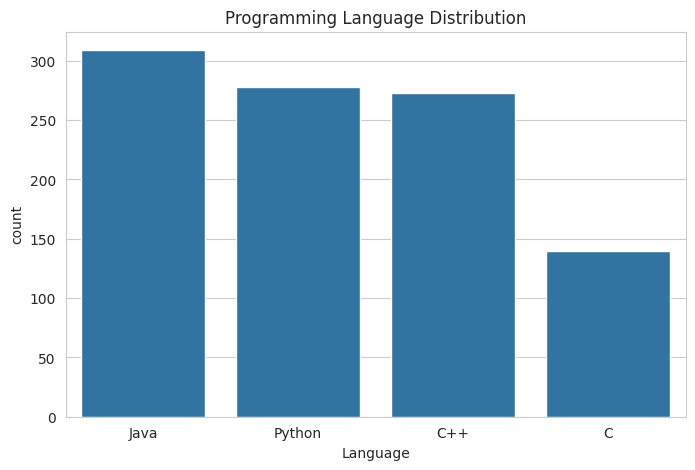

In [ ]:
print(
    final_df["Language"]
    .value_counts()
)

plt.figure(figsize=(8,5))

sns.countplot(
    data=final_df,
    x="Language",
    order=
    final_df["Language"]
    .value_counts()
    .index
)

plt.title(
    "Programming Language Distribution"
)

plt.show()

Source
CodeNet        350
ChatGPT-4      253
GitHub         150
ChatGPT-3.5     97
Claude          57
Gemini          50
ChatGPT         43
Name: count, dtype: int64


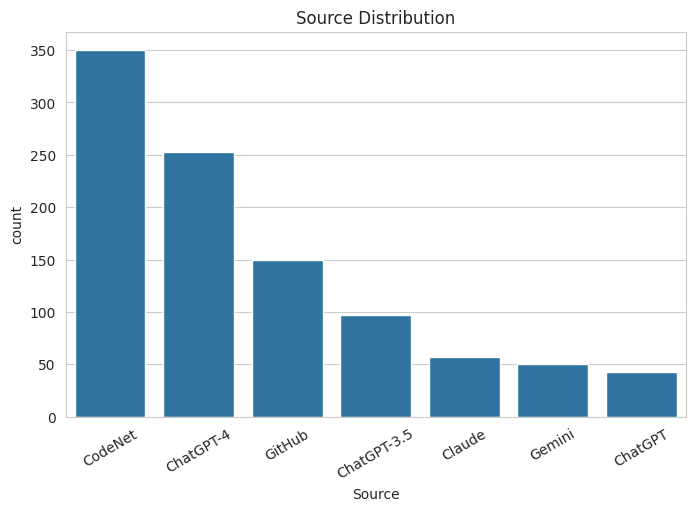

In [ ]:
print(
    final_df["Source"]
    .value_counts()
)

plt.figure(figsize=(8,5))

sns.countplot(
    data=final_df,
    x="Source",
    order=
    final_df["Source"]
    .value_counts()
    .index
)

plt.title(
    "Source Distribution"
)

plt.xticks(rotation=30)

plt.show()

,Code_Length
count,1000.000000
mean,1110.531000
std,1447.007658
min,63.000000
25%,357.750000
50%,589.500000
75%,1196.750000
max,15334.000000


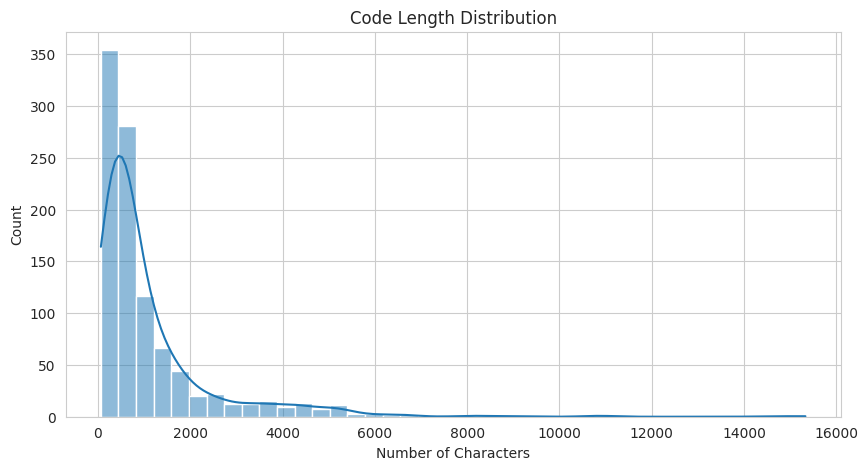

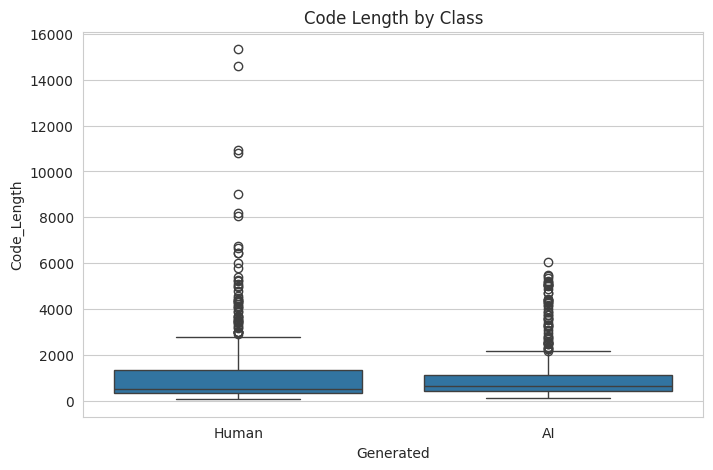

In [ ]:
final_df["Code_Length"] = (
    final_df["Sample_Code"]
    .astype(str)
    .apply(len)
)

display(
    final_df["Code_Length"]
    .describe()
)

plt.figure(figsize=(10,5))

sns.histplot(
    final_df["Code_Length"],
    bins=40,
    kde=True
)

plt.title(
    "Code Length Distribution"
)

plt.xlabel(
    "Number of Characters"
)

plt.show()

plt.figure(figsize=(8,5))

sns.boxplot(
    data=final_df,
    x="Generated",
    y="Code_Length"
)

plt.title(
    "Code Length by Class"
)

plt.show()

Generated,AI,Human
Language,,
C,79,61
C++,134,139
Java,139,170
Python,148,130


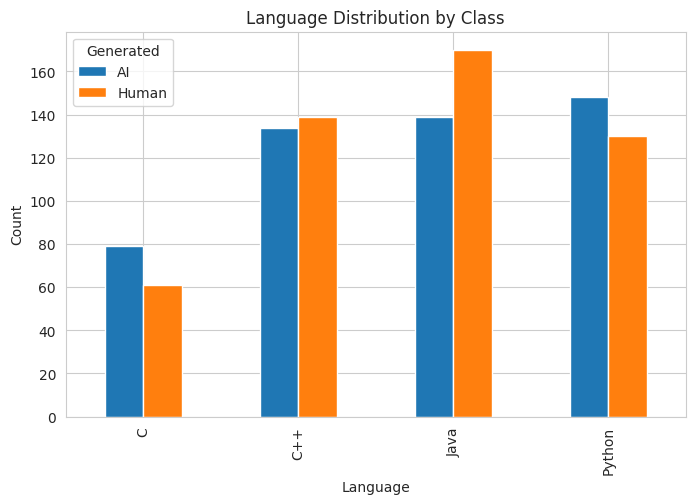

In [ ]:
language_cross = pd.crosstab(
    final_df["Language"],
    final_df["Generated"]
)

display(language_cross)

language_cross.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Language Distribution by Class"
)

plt.ylabel("Count")

plt.show()

Generated,AI,Human
Source,,
ChatGPT,43,0
ChatGPT-3.5,97,0
ChatGPT-4,253,0
Claude,57,0
CodeNet,0,350
Gemini,50,0
GitHub,0,150


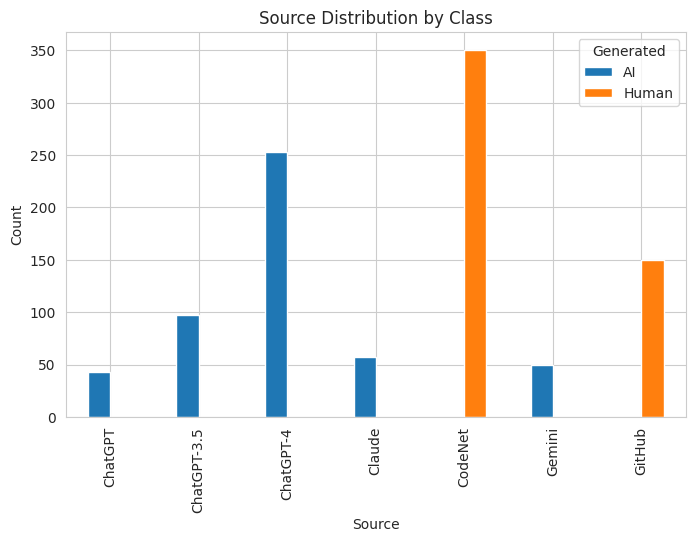

In [ ]:
source_cross = pd.crosstab(
    final_df["Source"],
    final_df["Generated"]
)

display(source_cross)

source_cross.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Source Distribution by Class"
)

plt.ylabel("Count")

plt.show()

In [ ]:
final_df[
    [
        "problem_id",
        "Language",
        "Generated",
        "Code_Length"
    ]
].sort_values(
    "Code_Length",
    ascending=False
).head(10)

,problem_id,Language,Generated,Code_Length
837,ProbSC138,Java,Human,15334
760,ProbSC061,Python,Human,14590
726,ProbSC027,C++,Human,10921
775,ProbSC076,Python,Human,10820
761,ProbSC062,Python,Human,9028
842,ProbSC143,C++,Human,8177
836,ProbSC137,Java,Human,8053
766,ProbSC067,Python,Human,6750
723,ProbSC024,C++,Human,6651
787,ProbSC088,Python,Human,6442


In [ ]:
print("="*50)
print("EDA SUMMARY")
print("="*50)

print(
    f"Total Data : {len(final_df)}"
)

print(
    f"Human      : {(final_df['Generated']=='Human').sum()}"
)

print(
    f"AI         : {(final_df['Generated']=='AI').sum()}"
)

print(
    f"Languages  : {final_df['Language'].nunique()}"
)

print(
    f"Sources    : {final_df['Source'].nunique()}"
)

print(
    f"Average Code Length : {final_df['Code_Length'].mean():.2f}"
)

print(
    f"Max Code Length : {final_df['Code_Length'].max()}"
)

print(
    f"Min Code Length : {final_df['Code_Length'].min()}"
)

EDA SUMMARY
Total Data : 1000
Human      : 500
AI         : 500
Languages  : 4
Sources    : 7
Average Code Length : 1110.53
Max Code Length : 15334
Min Code Length : 63
